#### Summary:
In this notebook I'll implement the final ATAC trait associations! Unlike with RNA, where we find major differences between the gene expression counts data, the ATAC data looks much more comparable between the two datasets. Thus, here we'll run DESeq on both datasets combined, including covariates for dataset and sequencing depth.

In [1]:
suppressMessages(library(dplyr)) 
suppressMessages(library(Matrix)) 
suppressMessages(library(data.table))
suppressMessages(library(future)) 
suppressMessages(library(stringr))
suppressMessages(library(stringi))
suppressMessages(library(readr))
suppressMessages(library(meta))

suppressMessages(library(ggplot2))
suppressMessages(library(ggpubr)) 
suppressMessages(library(ggrepel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(shadowtext))
suppressMessages(library(forcats))

suppressMessages(library(DESeq2))
suppressMessages(library(qvalue))
suppressMessages(library(parallel))
suppressMessages(library(bettermc))

# Basic Inputs

In [2]:
overall_outdir <- '/dir/with/phenotype/assoc/results'
outdir <- file.path(overall_outdir,'trait_associations')

In [3]:
#read in donor metadata and get lists of samples per study
meta_fp <- file.path(outdir, 'all_datasets_donor_combined_metadata_ATAC_fin.tsv')
meta <- read.table(meta_fp, sep='\t', header=1) %>%
            subset(dataset %in% c('Alberta','HPAP','Wang')) %>%
            subset(dataset!='Wang' | assays!='Multiome')

colnames(meta)
head(meta)

alberta_samples <- subset(meta, dataset=='Alberta') %>% pull(sample)
hpap_atac_samples <- subset(meta, dataset=='HPAP' & grepl('ATAC',assays)) %>% pull(sample)
wang_samples <- subset(meta, dataset=='Wang') %>% pull(sample)
wang_samples

[1] "sample"                        "age"                          
 [3] "scaled_age"                    "sex"                          
 [5] "BMI"                           "scaled_BMI"                   
 [7] "HbA1c"                         "scaled_HbA1c"                 
 [9] "dataset"                       "culture_time"                 
[11] "scaled_culture_time"           "TSSe"                         
[13] "scaled_TSSe"                   "tissue_source"                
[15] "chemistry"                     "assays"                       
[17] "race_ancestry_ethnicity"       "purity"                       
[19] "cause_of_death"                "num_cells_rna"                
[21] "num_cells_atac"                "beta_cells_rna"               
[23] "alpha_cells_rna"               "delta_cells_rna"              
[25] "gamma_cells_rna"               "acinar_cells_rna"             
[27] "ductal_cells_rna"              "endothelial_cells_rna"        
[29] "immune_cells_rna"              "stellate_cells_rna"           
[31] "beta_cells_atac"               "alpha_cells_atac"             
[33] "delta_cells_atac"              "gamma_cells_atac"             
[35] "acinar_cells_atac"             "ductal_cells_atac"            
[37] "endothelial_cells_atac"        "immune_cells_atac"            
[39] "stellate_cells_atac"           "beta_cells_rna_prop"          
[41] "scaled_beta_cells_rna_prop"    "beta_cells_atac_prop"         
[43] "scaled_beta_cells_atac_prop"   "beta_mean_genes"              
[45] "scaled_beta_mean_genes"        "alpha_mean_genes"             
[47] "scaled_alpha_mean_genes"       "delta_mean_genes"             
[49] "scaled_delta_mean_genes"       "gamma_mean_genes"             
[51] "scaled_gamma_mean_genes"       "acinar_mean_genes"            
[53] "scaled_acinar_mean_genes"      "ductal_mean_genes"            
[55] "scaled_ductal_mean_genes"      "endothelial_mean_genes"       
[57] "scaled_endothelial_mean_genes" "immune_mean_genes"            
[59] "scaled_immune_mean_genes"      "stellate_mean_genes"          
[61] "scaled_stellate_mean_genes"

,sample,age,scaled_age,sex,BMI,scaled_BMI,HbA1c,scaled_HbA1c,dataset,culture_time,⋯,acinar_mean_genes,scaled_acinar_mean_genes,ductal_mean_genes,scaled_ductal_mean_genes,endothelial_mean_genes,scaled_endothelial_mean_genes,immune_mean_genes,scaled_immune_mean_genes,stellate_mean_genes,scaled_stellate_mean_genes
,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,R207,50,0.39660887,Female,22.2,-1.1399660,NA,NA,Alberta,70,⋯,1462.876,-0.8582270,1842.333,-0.8810634,1304.000,-0.7786267,1118.606,-1.0135754,1314.583,-0.9680430
2,R217,71,1.57118130,Female,35.5,1.1019621,6.3,1.7633553,Alberta,15,⋯,1800.699,-0.4816742,1868.313,-0.8600477,1578.500,-0.4885881,1458.000,-0.3746634,1771.000,-0.5932814
3,R218,73,1.68304534,Female,28.4,-0.0948567,5.9,0.9489681,Alberta,70,⋯,1199.855,-1.1514019,1384.827,-1.2511587,1503.500,-0.5678336,910.250,-1.4058074,1505.200,-0.8115285
4,R221,44,0.06101675,Male,30.5,0.2591320,5.3,-0.2726127,Alberta,136,⋯,1315.754,-1.0222155,1625.554,-1.0564246,1376.625,-0.7018906,1460.600,-0.3697689,1243.706,-1.0262402
5,R223,54,0.62033695,Male,27.0,-0.3308491,5.8,0.7453713,Alberta,64,⋯,1562.639,-0.7470272,1854.044,-0.8715899,1592.143,-0.4741729,1568.125,-0.1673522,1826.053,-0.5480779
6,R226,30,-0.72203154,Female,32.3,0.5625508,4.9,-1.0869999,Alberta,16,⋯,1516.972,-0.7979293,2238.235,-0.5608025,1328.000,-0.7532682,2198.750,1.0198046,1739.250,-0.6193512


[1] "JYH792" "MM110"  "MM123"  "MM124"  "MM56"   "MM59"   "MM80"   "MM86"  
 [9] "MM89"   "MM95"   "MM98"

In [4]:
celltypes <- c('beta', 'alpha', 'delta', 'gamma', 'acinar','ductal', 'endothelial', 'immune','stellate')
celltype_colors = c('acinar'='#09850B', 'alpha'='#F51646', 'beta'='#3F98E0',
                    'delta'='#FFA946', 'ductal'='#F5DE6C', 'endothelial'='#752BBA', 
                    'gamma'='#A1D99B', 'immune'='#F598C9', 'stellate'='#AB7345')

In [5]:
theme_set(theme_classic())

In [6]:
datasets <- c('Alberta','HPAP','Wang')
meta_fin <- subset(meta, dataset %in% datasets & grepl('Multiome|ATAC',assays))
table(meta_fin$dataset)
all_samples <- meta_fin$sample
length(all_samples)
all_samples


Alberta    HPAP    Wang 
     28      27      11 

[1] 66

[1] "R207"     "R217"     "R218"     "R221"     "R223"     "R226"    
 [7] "R228"     "R234"     "R237"     "R238"     "R246"     "R247"    
[13] "R275"     "R284"     "R290"     "R292"     "R316"     "R317"    
[19] "R319"     "R325"     "R326"     "R327"     "R332"     "R353"    
[25] "R354"     "R362"     "R363"     "R364"     "HPAP-035" "HPAP-036"
[31] "HPAP-039" "HPAP-040" "HPAP-044" "HPAP-045" "HPAP-047" "HPAP-049"
[37] "HPAP-050" "HPAP-052" "HPAP-053" "HPAP-054" "HPAP-056" "HPAP-059"
[43] "HPAP-063" "HPAP-067" "HPAP-069" "HPAP-072" "HPAP-075" "HPAP-077"
[49] "HPAP-080" "HPAP-092" "HPAP-099" "HPAP-101" "HPAP-103" "HPAP-104"
[55] "HPAP-105" "JYH792"   "MM110"    "MM123"    "MM124"    "MM56"    
[61] "MM59"     "MM80"     "MM86"     "MM89"     "MM95"     "MM98"

# 1. Read in inputs previously generated (metadata df, cell type peaks lists)

## Read in cell type level called peaks (overlapping union peaks)

In [7]:
# Read in all celltype_peak files into a list
ct_peaks_list = list()
for (celltype in celltypes){
    peak.fp <- sprintf('/dir/with/peak/calls/%s.union_peaks.bed',celltype)
    ct.peaks <- read.table(peak.fp,sep='\t')
    ct_peaks <- paste(ct.peaks$V1,ct.peaks$V2,ct.peaks$V3,sep="-")
    ct_peaks_list[[celltype]] = ct_peaks
}

In [8]:
#OPTION: cut down ct peaks lists to just autosomal peaks!
ct_auto_peaks_list <- list()
for (celltype in celltypes){
    peaks <- ct_peaks_list[[celltype]]
    ct_auto_peaks_list[[celltype]] <- peaks[!grepl('chrX|chrY',ct_peaks_list[[celltype]])]
}

In [9]:
length(ct_peaks_list[['beta']])
length(ct_auto_peaks_list[['beta']])

[1] 128874

[1] 125823

In [10]:
head(ct_peaks_list[['beta']])

[1] "chr1-9956-10256"    "chr1-180714-181014" "chr1-181329-181629"
[4] "chr1-191340-191640" "chr1-267860-268160" "chr1-586035-586331"

# 2. Calculate Trait Associations with Peaks

## Run DESeq for all variables (age, BMI, HbA1c, sex)
Function design: `~main variable + other metadata + dataset + scaled_culture_time + scaled_beta_prop_atac + scaled_tsse`

In [11]:
mat_dir <- file.path(outdir, 'ATAC','final_matrices')
files <- list.files(mat_dir)
files

#exclude cell types that we don't have many donors with lots of cells in (endothelial)
#already did this by deleting softlinks for 3 small cell types
fin_files <- files

[1] "acinar_all_donor_peak_total_counts.tsv"     
[2] "alpha_all_donor_peak_total_counts.tsv"      
[3] "beta_all_donor_peak_total_counts.tsv"       
[4] "delta_all_donor_peak_total_counts.tsv"      
[5] "ductal_all_donor_peak_total_counts.tsv"     
[6] "endothelial_all_donor_peak_total_counts.tsv"
[7] "gamma_all_donor_peak_total_counts.tsv"      
[8] "immune_all_donor_peak_total_counts.tsv"     
[9] "stellate_all_donor_peak_total_counts.tsv"

In [12]:
### Function which runs the default DESeq analysis on each cell type total counts sample matrix
### focusing on one input variable (var), and including other_vars as covariates
### then sorts results by pvalue and writes to a file.
### Samples with NA values for the variable of interest (var) are removed, as well as samples with 
### no gex (eg some samples don't have schwann cells).

### New features: filter out genes with pseudobulk TPM < set cutoff, option to include scaled_mean_genes covar,
### writes outputs to a log file!
### 3/15/24: option to only use samples with a certain number of cells in the cell type

run_deseq_one_main_variable_ATAC <- function(files, var, other_vars, meta, out_prefix, log_fp, only_auto_peaks=TRUE, min_cells_per_sample=20){
    write(sprintf('Starting DESeq run for %s: %s', var, Sys.time()), file=log_fp, append=TRUE)
    
    for (FILE in files) {
        # Read in cell type counts file (sample pseudobulk)
        cell <- gsub('_all_donor_peak_total_counts.tsv', '', FILE)
        raw_counts <- read.table(file.path(mat_dir, FILE), row.names=1)
        raw_counts <- raw_counts[,(colSums(raw_counts != 0) > 0)]
        colnames(raw_counts) <- gsub('\\.','-',colnames(raw_counts))
        
        # Identify which samples we have gene expression and enough cells from
        samples <- meta$sample
        samples_notna <- subset(meta, !is.na(meta[[var]])) %>% pull(sample)
        samples_w_cells <- meta %>% subset(meta[[paste0(cell,'_cells_atac')]] >= 20 & num_cells_atac > 1000) %>% pull(sample)
        samples_fin <- samples[samples %in% samples_notna & samples %in% samples_w_cells]

        # Cut down matrices accordingly
        meta_fin <- (subset(meta, sample %in% samples_fin))
        row.names(meta_fin) <- meta_fin$sample
        raw_counts_fin <- raw_counts[,samples_fin]
        write(paste(cell, Sys.time(), length(samples_fin), 'samples to use'), file=log_fp, append=TRUE)
        write(paste(cell, Sys.time(), paste(samples_fin, collapse=',')), file=log_fp, append=TRUE)
        
        # If there are at least 10 samples with metadata, proceed with DESeq
        if (length(meta_fin[,var]) > 10){            
            # Light pre-filtering
            counts <- raw_counts_fin[rowSums(raw_counts_fin) >= 10,]
            write(paste(dim(counts)[1], 'peaks pass light pre-filtering (>= 10 counts across samples)'), file=log_fp, append=TRUE)
            
            # Filter peaks (raw_counts_fin) for those called in the cell type
            if(only_auto_peaks==TRUE) ct_peaks <- ct_auto_peaks_list[[cell]]
            if(only_auto_peaks==FALSE) ct_peaks <- ct_peaks_list[[cell]]
            counts_fin <- counts[row.names(counts) %in% ct_peaks,]
            write(paste(dim(counts_fin)[1], 'peaks called in cell type'), file=log_fp, append=TRUE)

            # Make function for DESeq using in the format: ~var + other_vars
            my_design <- as.formula(paste0(sprintf('~ %s',var),paste0(rep(' + ',length(other_vars)), other_vars,collapse='')))  
            write(as.character(my_design), file=log_fp, append=TRUE)
            print(my_design)
            
            # Run DESeq            
            dds  <- DESeqDataSetFromMatrix(round(counts_fin), colData = meta_fin, design = my_design) #colData is where design columns are found
            rld <- vst(dds)
            print(plotPCA(rld, intgroup = var)+ ggtitle(paste(cell,var)))
            dds <- DESeq(dds)
            
            # Extract results for variable of interest
            if (var == 'sex'){
                fin_var <- 'sex_Male_vs_Female'
            } else{
                fin_var <- var
            }
            res <- results(dds, name=fin_var)
            df <- as.data.frame(res)
            df <- df[order(df$pvalue),]
            fp <- paste0(out_prefix, cell, '.tsv')
            write.table(df, fp, sep="\t", quote=FALSE)
            write('\n', file=log_fp, append=TRUE)
        } else {
            write(paste(cell, Sys.time(), 'not enough samples to proceed!'), file=log_fp, append=TRUE)
        }
        write('', file=log_fp, append=TRUE)
    }
    write(paste('Done', Sys.time()), file=log_fp, append=TRUE)
}

In [13]:
#this takes longer to run than RNA (many more features to test), so gonna write a wrapper and parallelize by trait
atac_deseq_wrapper <- function(var, fin_files, deseq_outdir, variables, add_variables, meta_fin){
    # Make subdir in the outdir for the specific variable
    outdir_var <- file.path(deseq_outdir, var)
    dir.create(outdir_var, showWarnings = F)
    out_prefix <- file.path(outdir_var, sprintf('ATAC_deseq.%s.',var))
    log_fp <- file.path(deseq_outdir, sprintf('log_%s.txt', var))
    
    # Set other metadata variables to include in functions
    # removing HbA1c from other analyses for now since has NA values
    other_vars <- c(variables[variables != var & variables != 'scaled_HbA1c'] ,add_variables)

    # Run DESeq
    run_deseq_one_main_variable_ATAC(fin_files, var, other_vars, meta_fin, out_prefix, log_fp, only_auto_peaks=TRUE, min_cells_per_sample=20)
}

In [14]:
variables <- c('scaled_age', 'scaled_BMI', 'scaled_HbA1c', 'sex')
add_variables <- c('dataset', 'scaled_beta_cells_atac_prop', 'scaled_TSSe')

deseq_outdir <- file.path(outdir,'ATAC','DESeq')
dir.create(deseq_outdir, showWarnings=FALSE)

In [15]:
bettermc::mclapply(variables, atac_deseq_wrapper, fin_files, deseq_outdir, variables, add_variables, meta_fin,
                   mc.cores=4, mc.preschedule=FALSE)

0/1: ~scaled_age + scaled_BMI + sex + dataset + scaled_beta_cells_atac_prop + 
0/1:     scaled_TSSe
0/1: <environment: 0x55f44cdd50d8>
0/1: ~scaled_age + scaled_BMI + sex + dataset + scaled_beta_cells_atac_prop + 
0/1:     scaled_TSSe
0/1: <environment: 0x55f44cdd50d8>
0/1: ~scaled_age + scaled_BMI + sex + dataset + scaled_beta_cells_atac_prop + 
0/1:     scaled_TSSe
0/1: <environment: 0x55f44cdd50d8>
0/1: R_zmq_msg_send errno: 4 strerror: Interrupted system call
0/1: ~scaled_age + scaled_BMI + sex + dataset + scaled_beta_cells_atac_prop + 
0/1:     scaled_TSSe
0/1: <environment: 0x55f44cdd50d8>
0/1: R_zmq_msg_send errno: 4 strerror: Interrupted system call
0/1: ~scaled_age + scaled_BMI + sex + dataset + scaled_beta_cells_atac_prop + 
0/1:     scaled_TSSe
0/1: <environment: 0x55f44cdd50d8>
0/1: R_zmq_msg_send errno: 4 strerror: Interrupted system call
0/1: ~scaled_age + scaled_BMI + sex + dataset + scaled_beta_cells_atac_prop + 
0/1:     scaled_TSSe
0/1: <environment: 0x55f44cdd50d8>
0

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“0/1: some variables in design formula are characters, converting to factors”
Warning message in DESeqDataSet(se, design = design, ignoreRank):
“0/1: some variables in design formula are characters, converting to factors”
Warning message in DESeqDataSet(se, design = design, ignoreRank):
“0/1: some variables in design formula are characters, converting to factors”
Warning message in DESeqDataSet(se, design = design, ignoreRank):
“0/1: some variables in design formula are characters, converting to factors”
Warning message in DESeqDataSet(se, design = design, ignoreRank):
“0/1: some variables in design formula are characters, converting to factors”
Warning message in DESeqDataSet(se, design = design, ignoreRank):
“0/1: some variables in design formula are characters, converting to factors”
Warning message in DESeqDataSet(se, design = design, ignoreRank):
“0/1: some variables in design formula are characters, converting to f

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

# 3. Visualize summaries of DESeq results

In [17]:
#super brief summary of sig results from each association (in df form)
traits <- c('scaled_age', 'scaled_BMI', 'scaled_HbA1c', 'sex')

summary_df <- data.frame()
for(celltype in celltypes){
    num_sig <- c()
    for(trait in traits){
        fp <- file.path(deseq_outdir,trait,sprintf('ATAC_deseq.%s.%s.tsv',trait, celltype))
        df <- read.table(fp, sep='\t', header=1)
        sig_peaks <- row.names(subset(df, padj<0.1))
        num_sig <- c(num_sig,length(sig_peaks))
    }
    summary_df <- rbind(summary_df, num_sig)
}
row.names(summary_df) <- celltypes
colnames(summary_df) <- traits
summary_df

,scaled_age,scaled_BMI,scaled_HbA1c,sex
,<int>,<int>,<int>,<int>
beta,968,28,1,57
alpha,54,13,0,127
delta,4,0,1,15
gamma,0,2,0,16
acinar,14,14,4,24
ductal,0,0,0,2
endothelial,47,70,100,217
immune,57,13,104,234
stellate,0,1,18,15


## Basic summary plots

In [18]:
### Function to make a barplot comparing the # of significant DEGs for a list of cell types and variables
summarize_DEGs <- function(deseq_outdir, variables, celltypes, plot_col, colors){
    # Organize list of all outputs (celltype and variable)
    prefixes <- paste(rep(variables, each = length(celltypes)), celltypes, sep='-')
    
    # Read in all deseq_output files, save summary info to a list
    data <- data.frame()
    for (prefix in prefixes){
        var <- str_split(prefix, '-')[[1]][1]
        cell <- str_split(prefix, '-')[[1]][2]
        fp <- file.path(deseq_outdir, var, sprintf('ATAC_deseq.%s.%s.tsv',var, cell))
        df <- read.table(fp, sep='\t', header=TRUE)
        
        # Collect summary information into a vector
        num_tested <- dim(df)[1]
        num_sig <- dim(df[df$padj <= 0.1 & !is.na(df$padj),])[1]
        num_sig_pos <- dim(df[df$padj <= 0.1 & !is.na(df$padj) & df$log2FoldChange > 0,])[1]
        num_sig_neg <- dim(df[df$padj <= 0.1 & !is.na(df$padj) & df$log2FoldChange < 0,])[1]
        data <- rbind(data, c(num_tested, num_sig, num_sig_pos, num_sig_neg))
    }
    
    # Clean up dataframe
    row.names(data) <- prefixes
    colnames(data) <- c('genes_tested', 'sig_genes', 'pos_sig_genes', 'neg_sig_genes')
    data$variable <- str_split_fixed(prefixes, '-', 2)[,1]
    data$celltype <- str_split_fixed(prefixes, '-', 2)[,2]
    #print(data)
    
    # replace column name of plot_col with literally "plot_col" and make colors vector
    data$plot_col <- data[,plot_col]
    
    # Make grouped barplot of desired metadata
    options(repr.plot.width=30, repr.plot.height=8)
    theme_set(
        theme_classic())
    
    p1 <- ggplot(data, aes(fill=celltype, y=plot_col, x=variable)) + 
            geom_bar(position="dodge", stat="identity", width=0.7) + 
            labs(x = "Cell type", y = plot_col, color="Cell Type") + 
            scale_fill_manual(values=colors) + 
            theme(axis.text.x=element_text(size=20, vjust=0.5),
            axis.text.y=element_text(size=20, vjust=0.5),
            axis.title.x = element_text(size=25, vjust=-0.35),
            axis.title.y = element_text(size=25, vjust=0.5),
            legend.title = element_blank(),
            legend.text = element_text(size=15),
            plot.title = element_text(size=25, hjust=0.5, face="bold"))
    print(p1)
    
}

In [19]:
### Function to make a barplot comparing the chromosomes which DEGs come from (specifically for sex results)
### designed for one variable only
summarize_DEGs_chroms_ATAC <- function(deseq_outdir, var, celltypes, ref_df, colors){
    # Read in DESeq outputs and record chromosome distribution of genes    
    test_list <- list()

    for (cell in celltypes){
        fp <- file.path(deseq_outdir, var, sprintf('ATAC_deseq.%s.%s.tsv',var, cell))
        df <- read.table(fp, sep='\t', header=TRUE)
        df_cut <- df[df$padj <= 0.1 & !is.na(df$padj),]
        #get chroms for each peak
        peaks <- as.data.frame(str_split_fixed(row.names(df_cut),'-',3))
        test_list[[cell]] <- table(peaks$V1)
    }
    
    # Reformat into dataframe
    data <- plyr::ldply(test_list, rbind)
    chromosomes <- paste0('chr',c(as.character(seq(1,22)),'X','Y'))
    prev_chroms <- colnames(data)
    missing_chroms <- chromosomes[!chromosomes %in% colnames(data)]
    for (chrom in missing_chroms){
        new_col <- rep(NA, dim(data)[1])
        data <- cbind(data, new_col)
    }
    colnames(data) <- c(prev_chroms, missing_chroms)
    data2 <- t(data[,-1])
    colnames(data2) <- celltypes
    data2[is.na(data2)] <- 0
    data_fin <- data2[chromosomes,]

    # final df reformatting for ggplot
    df <- reshape2::melt(data_fin)
    colnames(df) <- c('chrom', 'celltype', 'num_genes')
    
    # Make grouped barplot of #genes in each celltype by chromosome
    options(repr.plot.width=24, repr.plot.height=8)
    theme_set(
        theme_classic())
    
    p1 <- ggplot(df, aes(fill=celltype, y=num_genes, x=chrom)) + 
            geom_bar(position="dodge", stat="identity", width=0.7) + 
            labs(x = "Celltype", y = 'Number of peaks', color="Cell Type", title=var) + 
           scale_fill_manual(values=colors) + 
            theme(axis.text.x=element_text(size=20, vjust=0.5),
            axis.text.y=element_text(size=20, vjust=0.5),
            axis.title.x = element_text(size=25, vjust=-0.35),
            axis.title.y = element_text(size=25, vjust=0.5),
            legend.title = element_blank(),
            legend.text = element_text(size=15),
            plot.title = element_text(size=25, hjust=0.5, face="bold"))
    print(p1)
}

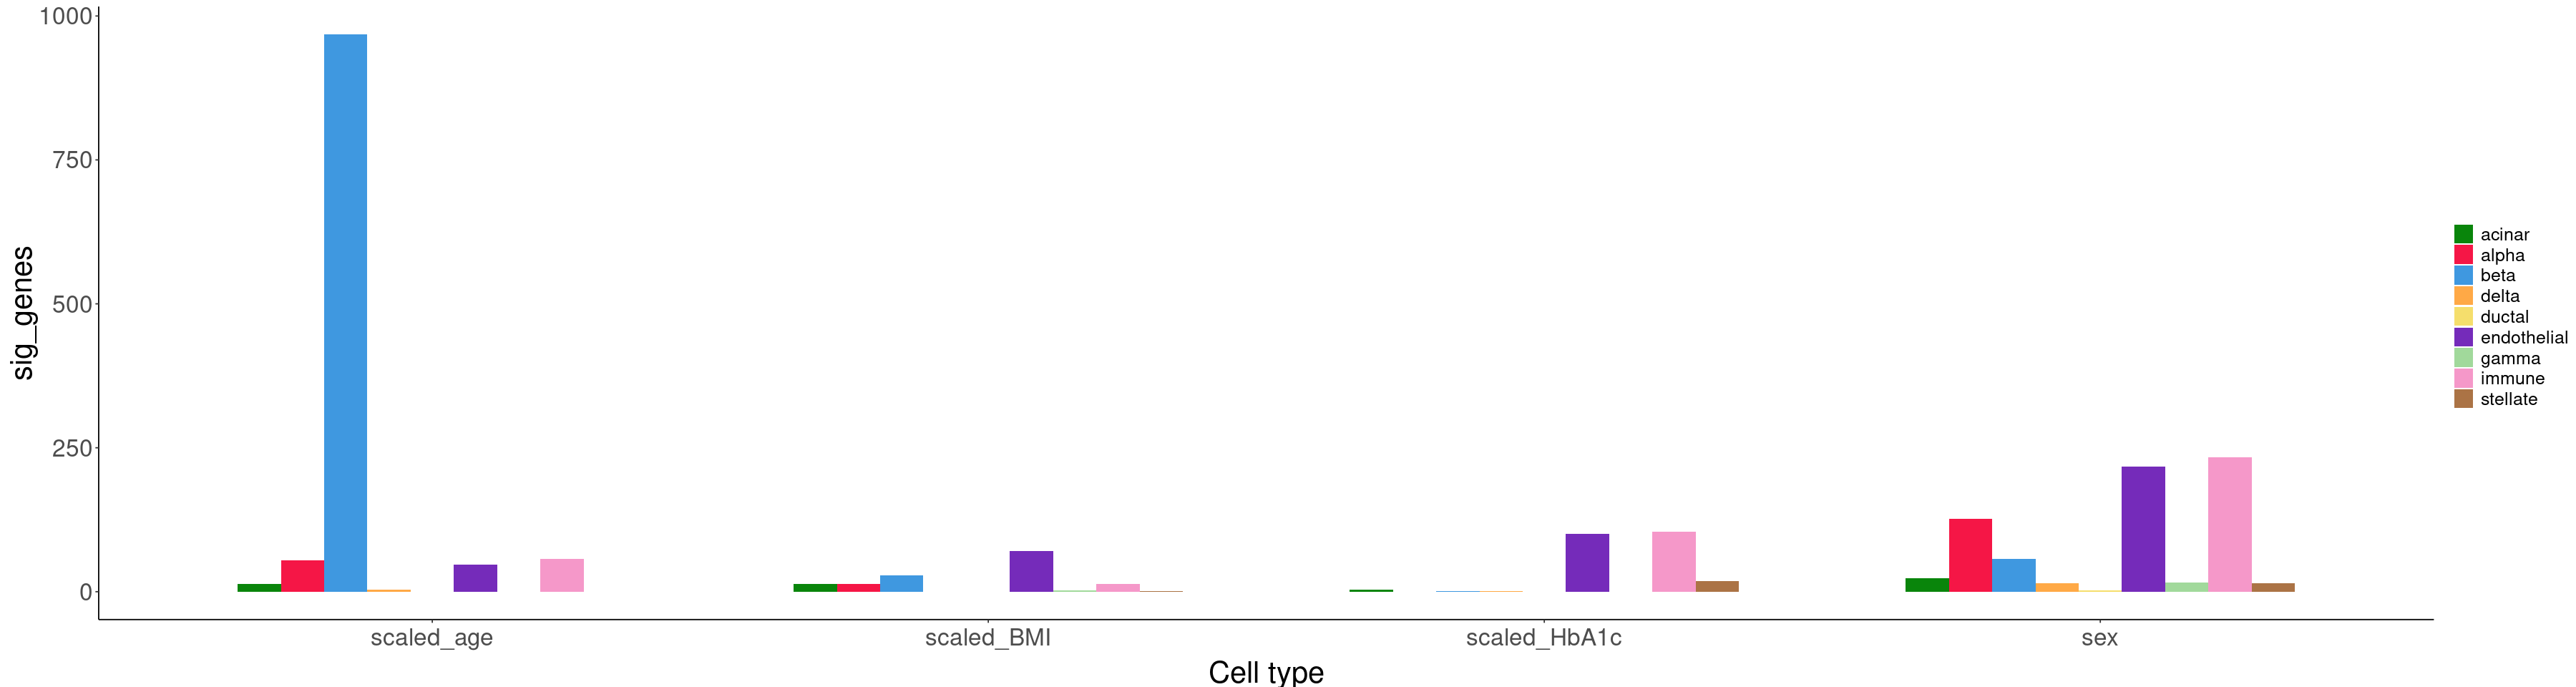

In [20]:
variables <- c('scaled_age', 'scaled_BMI', 'scaled_HbA1c', 'sex')
summarize_DEGs(deseq_outdir, variables, celltypes,'sig_genes', celltype_colors)

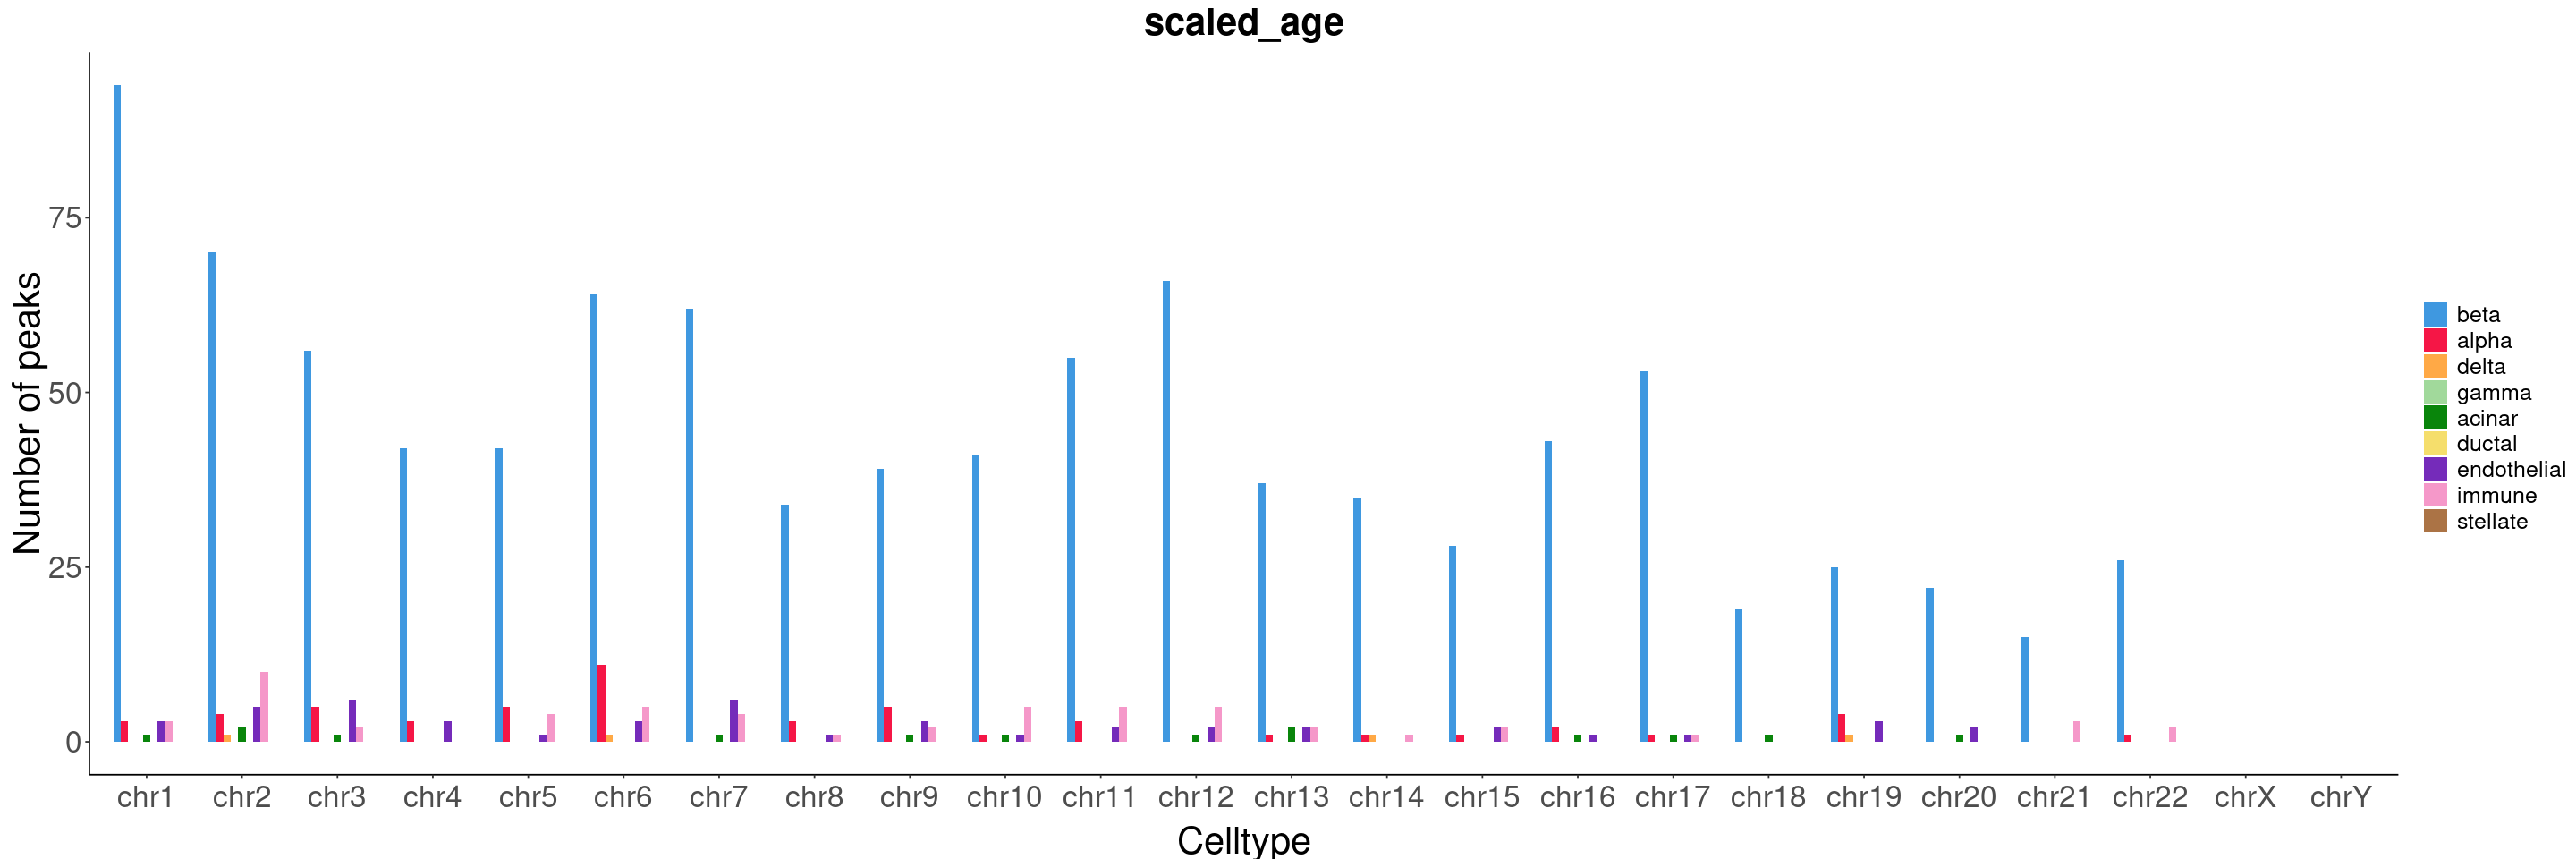

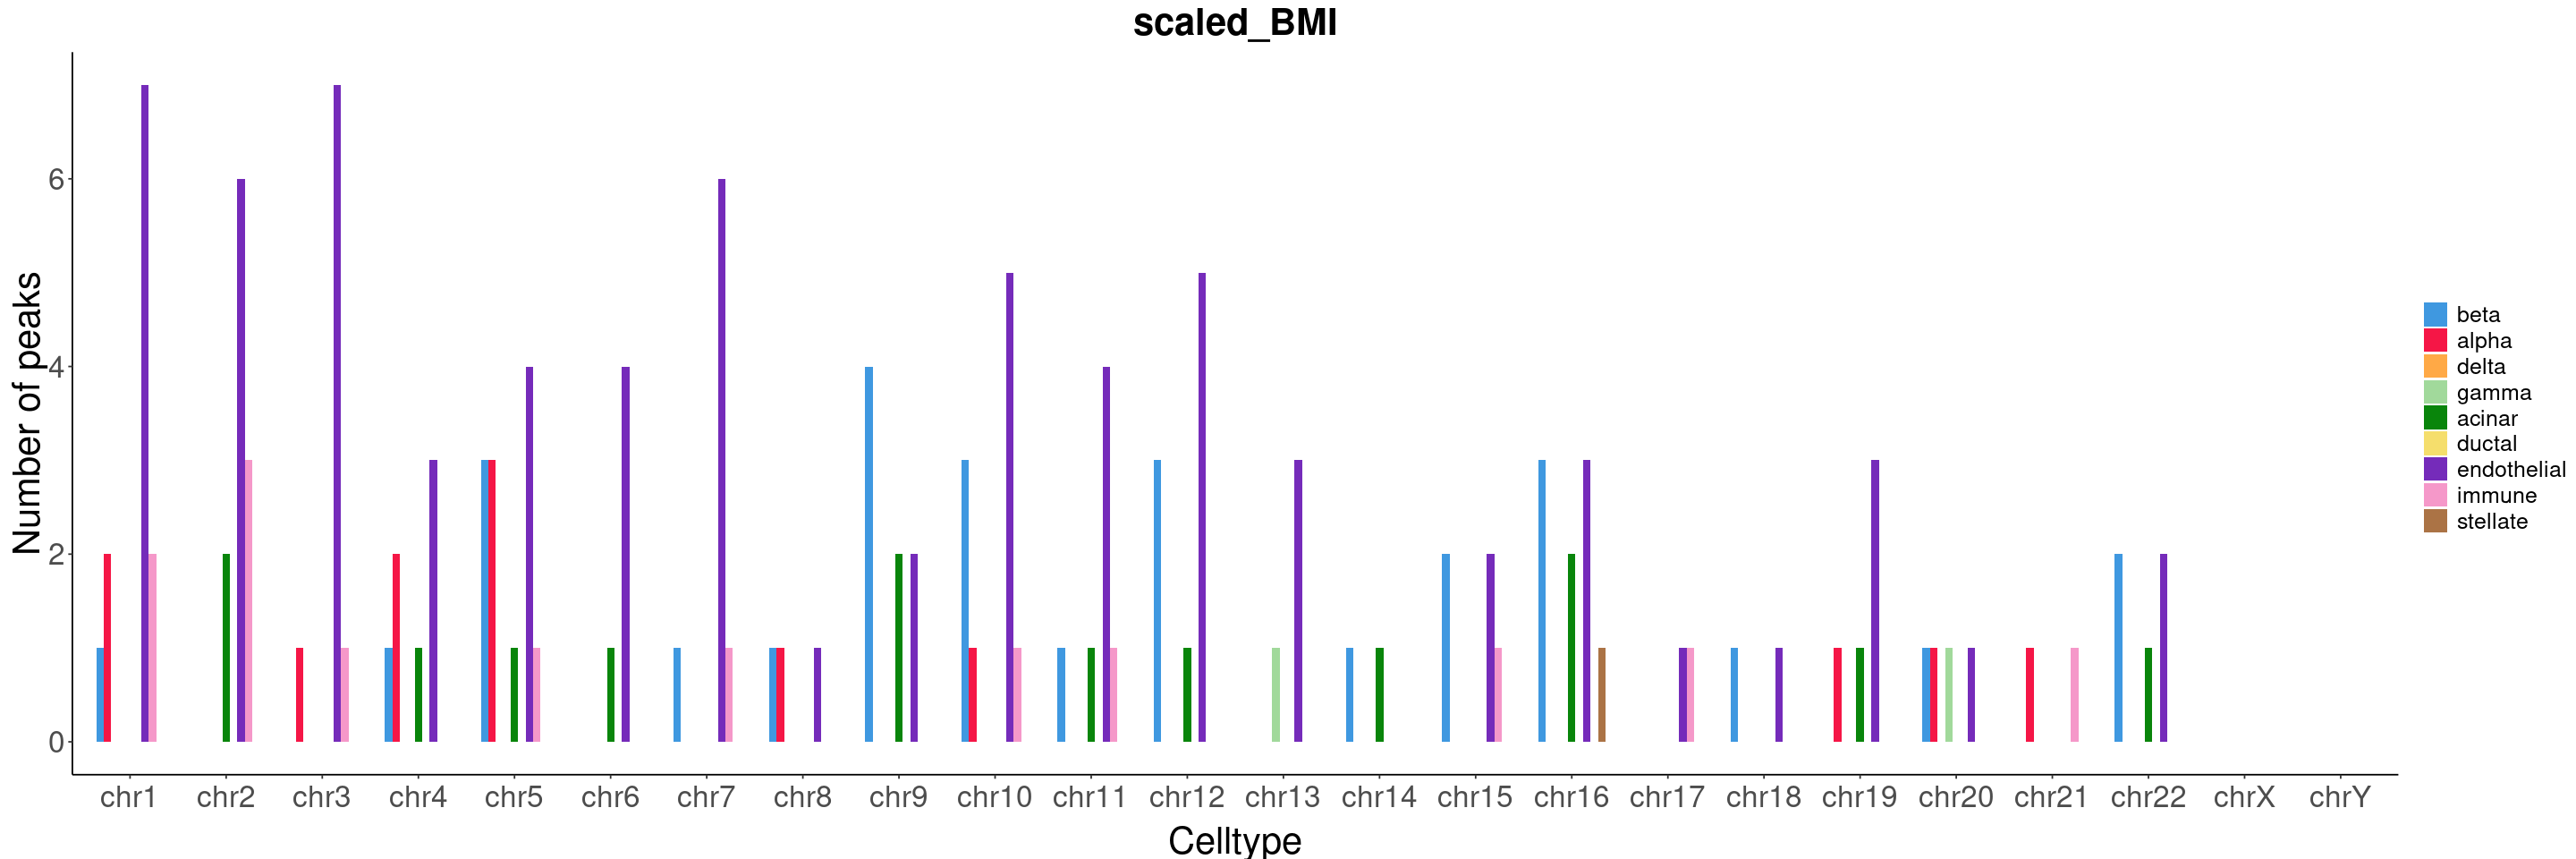

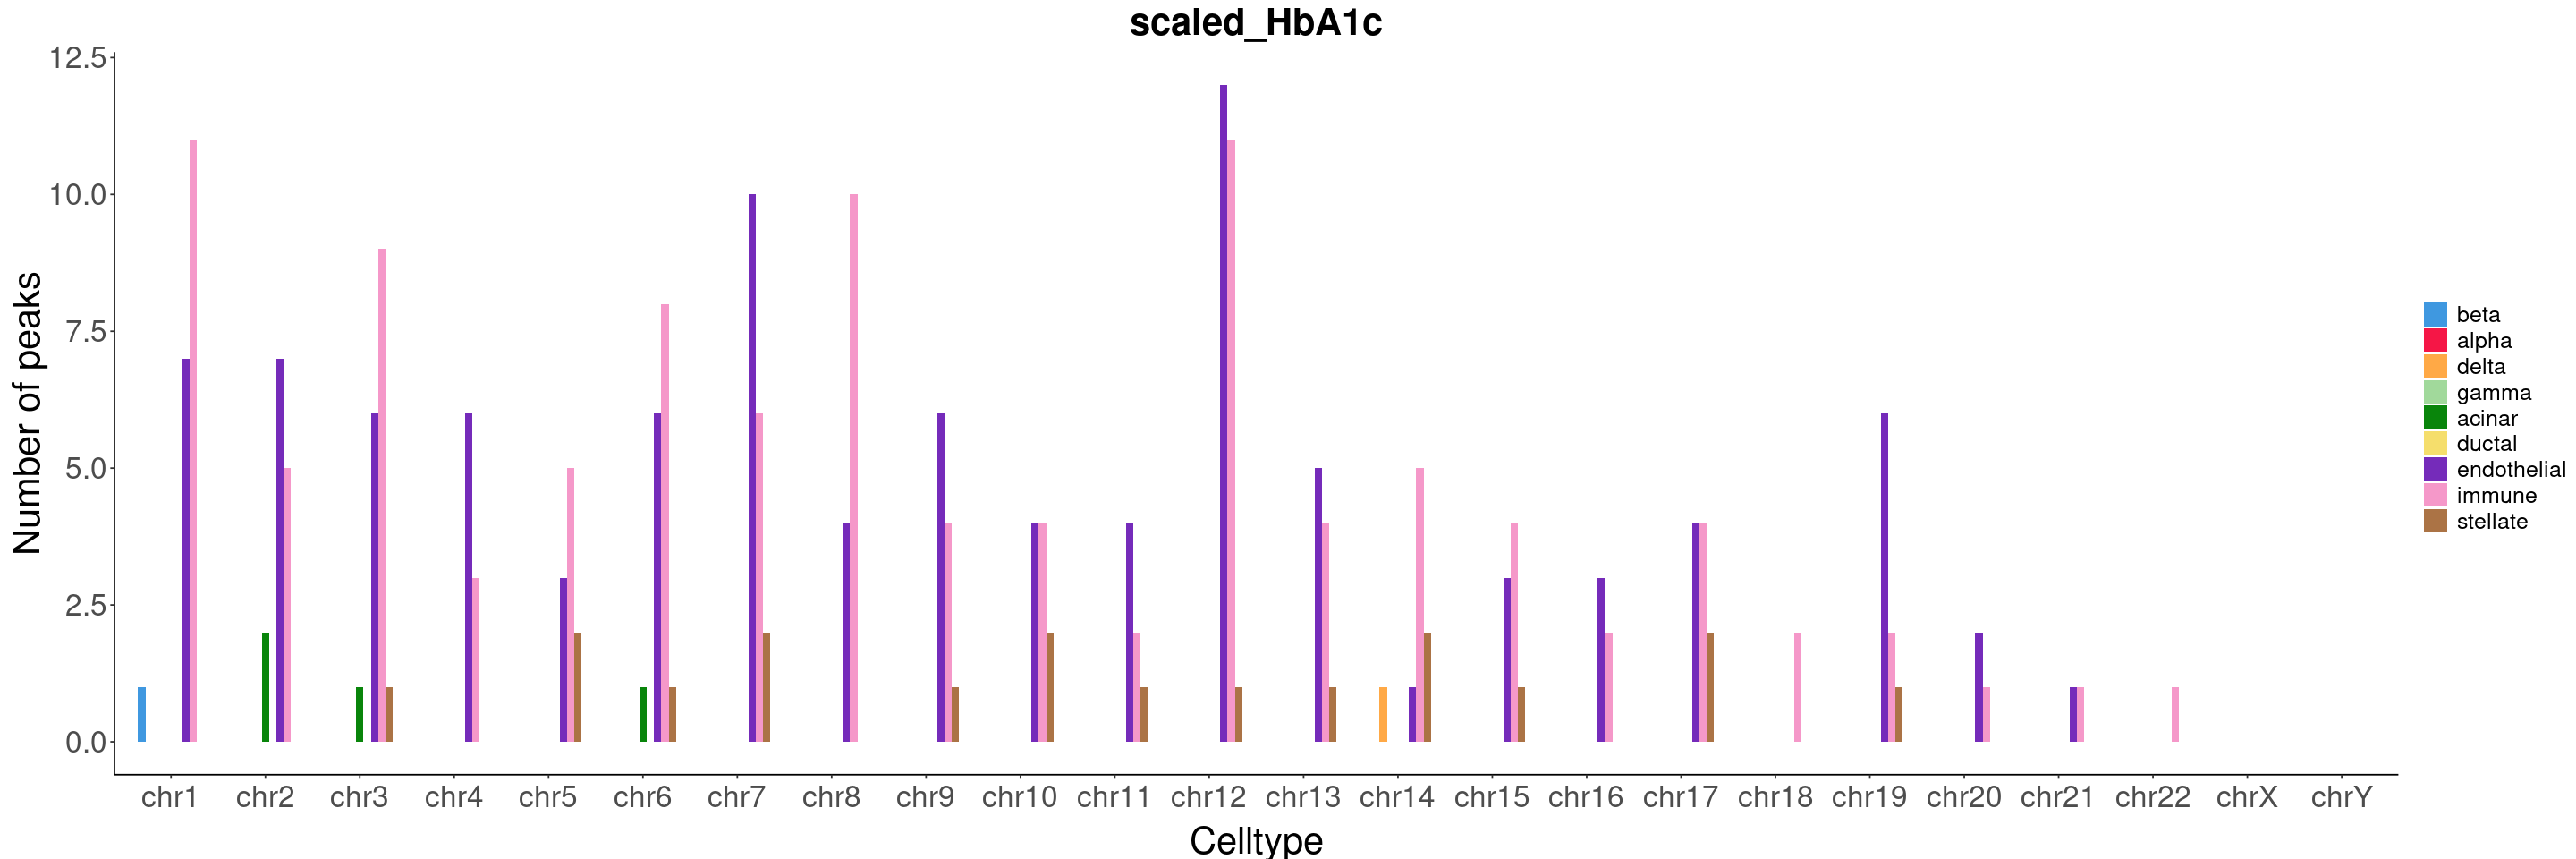

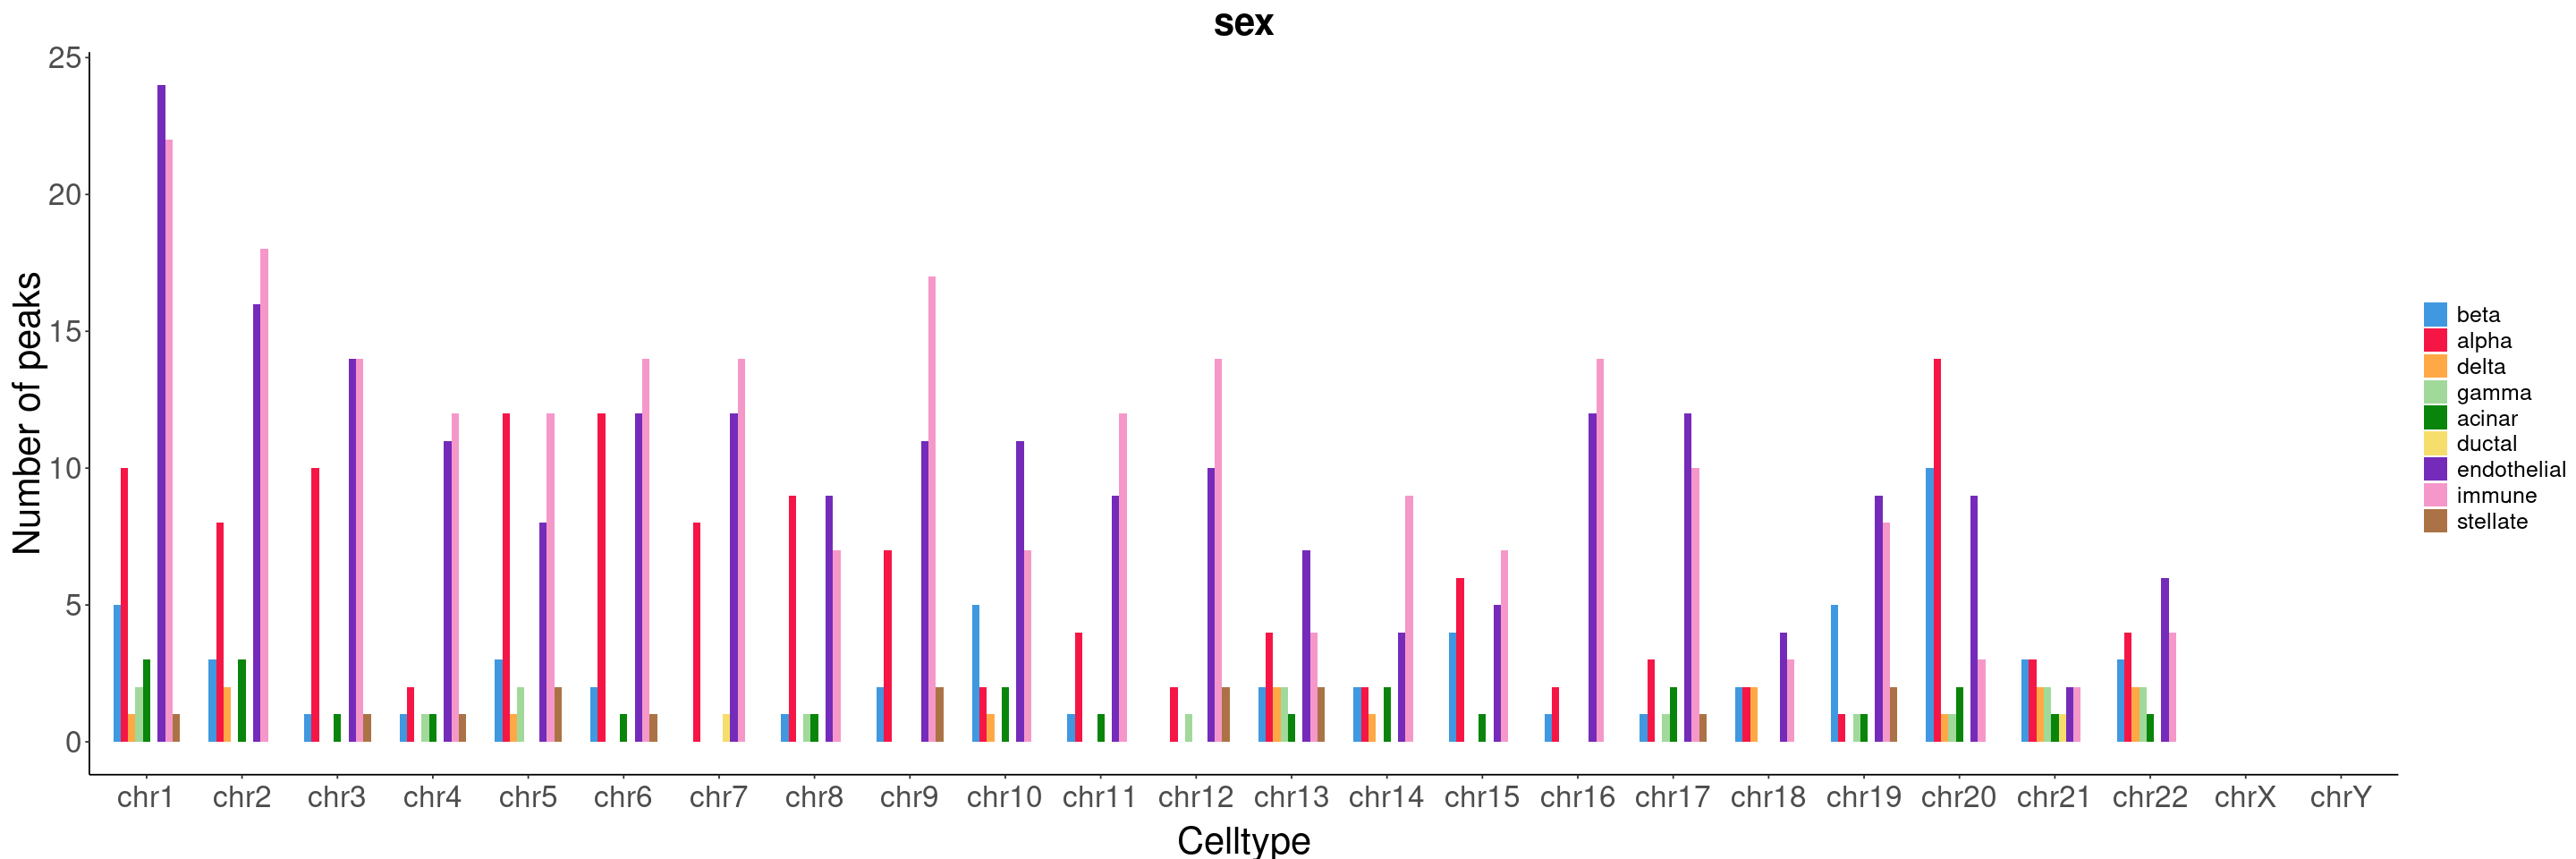

In [21]:
ref_df <- read.table('/non-diabetic-islet-multiomics/references/gene_coords.gencodev32.hg38.bed', sep='\t', header=FALSE)
variables <- c('scaled_age', 'scaled_BMI', 'scaled_HbA1c', 'sex')
for (var in variables){
    summarize_DEGs_chroms_ATAC(deseq_outdir, var, celltypes, ref_df, celltype_colors)    
}

In [2]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.2 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.9.0
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] bettermc_1.1.2              qvalue_2.26.0              
 [3] DESeq2_1.34.0               SummarizedExperiment_1.24.0
 [5] Biobase_2.54.0              MatrixGenerics_1.6.0       
 [7] matrixStats_1.3.0           GenomicRanges_1.46.1       
